Importing Libraries

In [85]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (classification_report,confusion_matrix,ConfusionMatrixDisplay,accuracy_score)

Parsing the data into Dataframe


In [86]:
df = pd.read_csv("data2.csv")
df.head(10)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
5,5,35,male,1,free,NaN,NaN,9055,36,education,good
6,6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good
7,7,35,male,3,rent,little,moderate,6948,36,car,good
8,8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
9,9,28,male,3,own,little,moderate,5234,30,car,bad


In [87]:
df.shape

(1000, 11)

In [88]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [89]:
df.info() # info about the datatypes and null values

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


Dropping columns not required

In [90]:
df = df.drop(columns=["Unnamed: 0"])

Handling Missing Values

In [91]:
df.isnull().sum() #sum of missing values in each column

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [92]:
#filling the missing values with unknown
df["Saving accounts"] = df["Saving accounts"].fillna("unknown")

df["Checking account"] = df["Checking account"].fillna("unknown")

In [93]:
df.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

Target Variable

In [94]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

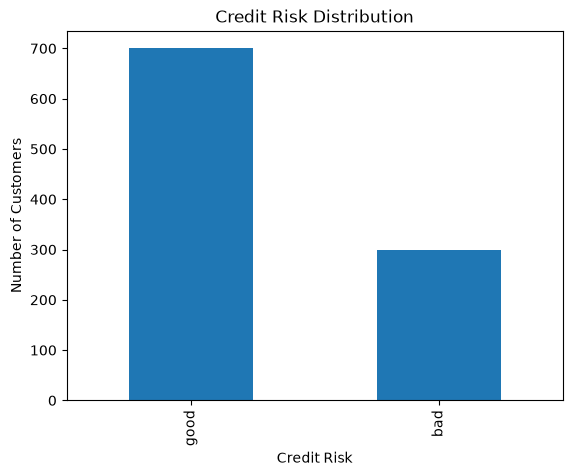

In [95]:
df["Risk"].value_counts().plot(kind="bar")

plt.title("Credit Risk Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Customers")
plt.show()

Converting target variable to numerical values


In [96]:
good = 0
bad = 1
df["Risk"] = df["Risk"].map({
    "good": 0,
    "bad": 1
})

Machine Learning

In [97]:
# Split the dataset into features and target variable
X = df.drop(columns=["Risk"])

y = df["Risk"]

In [98]:
X.select_dtypes(include="object").columns

/var/folders/jw/9g19xnb958jd_s734z_95nnr0000gn/T/ipykernel_22412/2213039483.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='str')

In [ ]:
# the computer does not understand categorical variables, so we converted into numerical variables using one hot encoding.
# One hot encoding creates new columns for categorical variables for each unique value a column contains.
# It assigns a 1 or 0 / True or False to each column based on whether the original column's value matches the unique value represented by that column.

X = pd.get_dummies(X, drop_first=True)

In [100]:
X.head()

,Age,Job,Credit amount,Duration,Sex_male,Housing_own,Housing_rent,Saving accounts_moderate,Saving accounts_quite rich,Saving accounts_rich,...,Checking account_moderate,Checking account_rich,Checking account_unknown,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,1169,6,True,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,22,2,5951,48,False,True,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False
2,49,1,2096,12,True,True,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
3,45,2,7882,42,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,53,2,4870,24,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [ ]:
#stratify = y is used to ensure that the class distribution in the training and testing sets is similar to the original dataset. 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
#using standard scaler to scale the features and logistic regression as the model for prediction. Using a pipeline to combine both steps.
# class weight = balanced is used to handle the class imbalance in the dataset. It assigns weights to the classes inversely proportional to their frequencies, giving more importance to the minority class (bad credit risk) during model training. This helps improve the model's ability to correctly classify instances of the minority class, leading to better overall performance on imbalanced datasets.
model = Pipeline([
    ("scaler", StandardScaler()),
    
    ("logistic_regression", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

In [103]:
#training the model using the training data
model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('logistic_regression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [104]:
y_pred = model.predict(X_test)


Results

In [105]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 70.00%


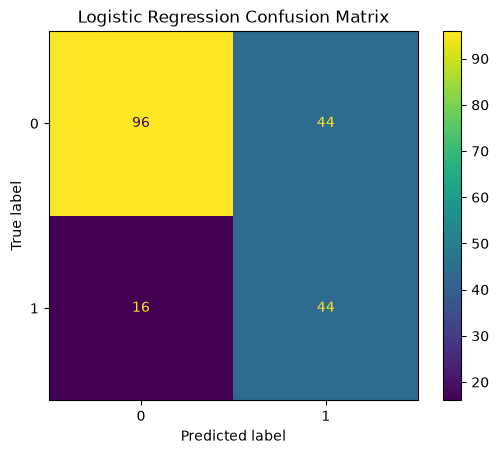

In [106]:
#confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()


In [107]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.69      0.76       140
           1       0.50      0.73      0.59        60

    accuracy                           0.70       200
   macro avg       0.68      0.71      0.68       200
weighted avg       0.75      0.70      0.71       200



Insights on which features contributed the most in Logistic Regression

In [ ]:

log_model = model.named_steps["logistic_regression"]

In [109]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

In [ ]:
#absolute value of the coefficients is calculated to identify the features with the highest impact on the model's predictions.
coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient,Absolute_Coefficient
13,Checking account_unknown,-0.822868,0.822868
3,Duration,0.441425,0.441425
10,Saving accounts_unknown,-0.326861,0.326861
9,Saving accounts_rich,-0.273628,0.273628
4,Sex_male,-0.194303,0.194303
16,Purpose_education,0.190936,0.190936
18,Purpose_radio/TV,-0.172296,0.172296
12,Checking account_rich,-0.149001,0.149001
11,Checking account_moderate,-0.140042,0.140042
8,Saving accounts_quite rich,-0.115831,0.115831


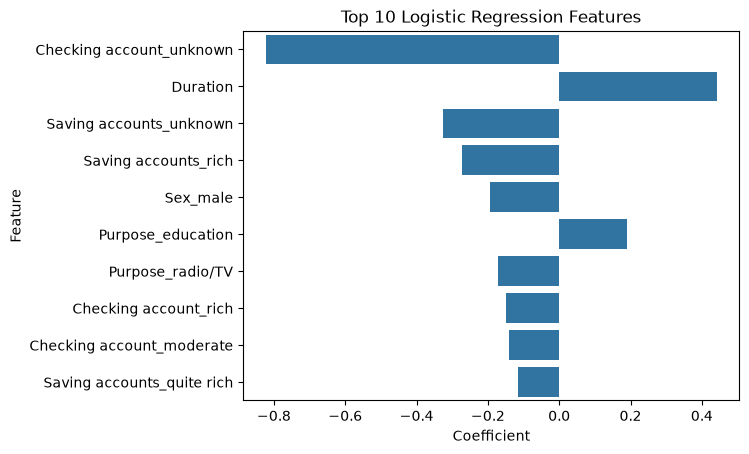

In [ ]:
#plotting the top 10 features with the highest absolute coefficients from the logistic regression model.
top10 = coefficients.head(10)

sns.barplot(
    data=top10,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Logistic Regression Features")
plt.show()

Random Forest

In [112]:
#class weight = bslanced is used to handle the class imbalance in the dataset. 
# It assigns weights to the classes inversely proportional to their frequencies, giving more importance to the minority class (bad credit risk) during model training. This helps improve the model's ability to correctly classify instances of the minority class, leading to better overall performance on imbalanced datasets.
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

random_forest.fit(X_train, y_train)

random_forest_pred = random_forest.predict(X_test)


Results

In [113]:
accuracy = accuracy_score(y_test, random_forest_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 74.00%


In [114]:
print(classification_report(y_test,random_forest_pred))

              precision    recall  f1-score   support

           0       0.77      0.89      0.83       140
           1       0.61      0.38      0.47        60

    accuracy                           0.74       200
   macro avg       0.69      0.64      0.65       200
weighted avg       0.72      0.74      0.72       200



Insights on which Features contributed the most in Random Forest


In [115]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

In [ ]:
#importance scores from the random forest model are sorted in descending order to identify the most dominating features for the prediction.
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance.head(10)

,Feature,Importance
2,Credit amount,0.214360
0,Age,0.168129
3,Duration,0.155933
13,Checking account_unknown,0.104004
1,Job,0.055082
10,Saving accounts_unknown,0.035404
4,Sex_male,0.032924
11,Checking account_moderate,0.027812
14,Purpose_car,0.026386
5,Housing_own,0.024659


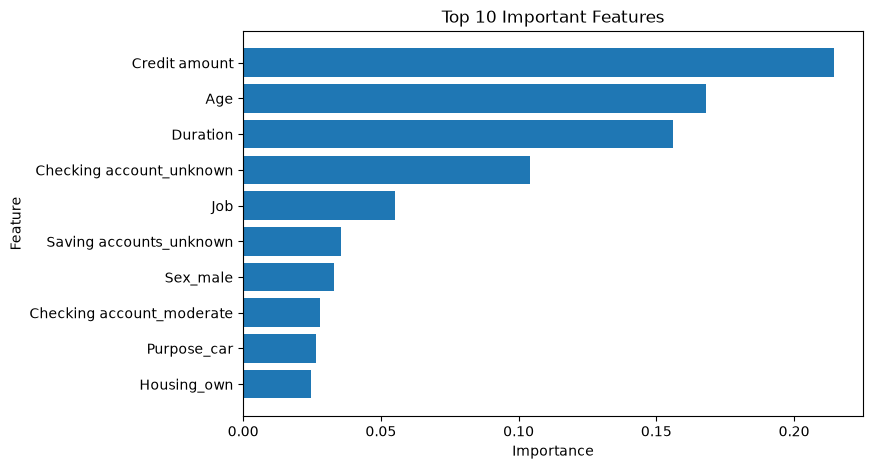

In [117]:
top_features = importance.head(10)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()